# Assigning Simulated FRBs to Host Galaxies

This notebook demonstrates how to use the `astropath.simulations.assign_host` module to assign simulated FRBs to host galaxies from a wide-field optical catalog. First, you should run the `astropath.simulations.generate_frbs` module (see the `Simulate_Generate_FRBs.ipynb` notebook) to generate the expected apparent magnitude distribution of host galaxies detected from a particular FRB survey.

You will also need to download the combined catalog of possible host galaxies sourced from the HECATE ($10 < m_r < 14$) + DECaLs ($14 < m_r < 22$) + HSC ($22 < m_r < 28$) surveys (see Section 3.2 of Andersen+26). To do this, download the `combined_HSC_DECaLs_HECATE_galaxies_hecatecut.parquet` file at this Google Drive link: [link](https://drive.google.com/drive/folders/1KMP4H0ETh_wpBI6B0vBhOsXmTWE_jYzL?usp=drive_link)

This will be replaced with a more robust Dryad link upon journal submission of Andersen+26.

To summarize the host assignment process:
1. **Matching Apparent Magnitude**: FRBs are distributed into real galaxies on-sky using existing wide-field optical surveys according to the simulated apparent magnitude distribution from `astropath.simulations.generate_frbs`.
2. **Simulating True Galactocentric Offset**: Once assigned a host galaxy, FRBs are then randomly placed *within* their host assuming some form for the intrinsic FRB galactocentric offset distribution (by default, a radial exponential $\propto \exp(-\theta/(\mathrm{scale} \cdot \phi))$).
3. **Apply Localization Offset**: 

The result is a `pandas.DataFrame` with information about the matched host, true FRB offset, and observed localization:
- `FRB_ID`: original FRB index in input DataFrame
- `gal_ID`: the ID of the host galaxy in its original optical survey (HECATE, DECaLs, HSC)
- `mag`: the r-band magnitude of the host galaxy
- `half_light`: the half-light radius of the host galaxy (arcsec)
- `true_ra`: the true right ascension of the FRB (degrees)
- `true_dec`: the true declination of the FRB (degrees)
- `gal_off`: offset due to intrinsic FRB distribution (arcsec)
- `loc_off`: offset due to localization (arcsec)
- `ra`: right ascension of the observed localization center (degrees)
- `dec`: declination of the observed localization center (degrees)
- `a`: semi-major axis of the localization (arcsec)
- `b`: semi-minor axis of the localization (arcsec)
- `PA`: position angle of the localization (degrees East of North)

In [1]:
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
params = {'axes.labelsize':20,
         'axes.titlesize':20,
         'xtick.labelsize':20,
         'ytick.labelsize':20}
pylab.rcParams.update(params)
from matplotlib import rc
rc('text', usetex=False)
import matplotlib
import matplotlib.ticker as ticker

import os
import numpy as np
import pandas as pd
from pathlib import Path
from matplotlib.patches import Ellipse
from astropy import units

In [2]:
from astropath.simulations import generate_frbs, assign_frbs_to_hosts, load_galaxy_catalog
from importlib.resources import files

If you wish to use the halos modules, you need the Aemulus HMF emulator. Please install it: github.com/AemulusProject/hmf_emulator
If you wish to use the halos modules, you need the Aemulus HMF emulator. Please install it: github.com/AemulusProject/hmf_emulator


## Step 1: Generate an FRB Population from a Radio Survey

First, we generate a population of FRBs using `generate_frbs()`. This gives us simulated FRBs with extragalactic DMs, redshift, and host galaxy apparent magnitude distributions (see the `Simulate_Generate_FRBs.ipynb` notebook).

In [3]:
# Generate 500 CHIME FRBs following the Catalog 1 DM distribution with S/N > 12
n_frbs = 10000
seed = 42

fn = files('astropath.data') / 'frb_surveys' / 'chimefrbcat1.csv'
df_dr1 = pd.read_csv(fn)
chime_dms_eg = np.nanmean([df_dr1['dm_exc_ne2001'].values,df_dr1['dm_exc_ymw16'].values], axis=0)
chime_snrs = df_dr1['bonsai_snr']
threshold = 12.
chime_observed_dms_eg = chime_dms_eg[chime_snrs > threshold]

frbs = generate_frbs(n_frbs, 'CHIME', seed=seed, 
        dm_catalog=chime_observed_dms_eg)

print(f"Generated {len(frbs)} FRBs")
print(f"\nFRB properties:")
print(f"  DM range:  {frbs['DMeg'].min():.0f} - {frbs['DMeg'].max():.0f} pc/cm³")
print(f"  z range:   {frbs['z'].min():.3f} - {frbs['z'].max():.3f}")
print(f"  M_r range: {frbs['M_r'].min():.2f} - {frbs['M_r'].max():.2f}")
print(f"  m_r range: {frbs['m_r'].min():.2f} - {frbs['m_r'].max():.2f}")

frbs

Loading P(DM,z) grid from /Users/bandersen/miniforge3/envs/frbs2/lib/python3.11/site-packages/frb/data/DM/CHIME_pzdm.npz
Sampling DM values
Sampling redshifts
Sampling host galaxy absolute magnitudes
Using Lz values to sample host galaxy absolute magnitudes
Generated 10000 FRBs

FRB properties:
  DM range:  0 - 2238 pc/cm³
  z range:   0.010 - 2.903
  M_r range: -24.26 - -15.04
  m_r range: 10.83 - 29.94


,DMeg,z,M_r,m_r
0,332.858066,0.221886,-19.342392,20.936612
1,1310.849406,0.749654,-21.684089,21.707284
2,701.321672,0.261600,-21.078341,19.605157
3,535.564011,0.522973,-19.686265,22.757251
4,166.115017,0.121848,-20.544966,18.302279
...,...,...,...,...
9995,977.803100,1.228128,-17.529632,27.180218
9996,1096.557454,0.112349,-19.247634,19.410042
9997,1288.693992,0.678818,-22.786734,20.341637
9998,351.140944,0.264891,-20.873681,19.840740


## Step 2: Load Catalog of Possible Host Galaxies

We'll use a real galaxy catalog if available (the combined HECATE + DECaLs + HECATE catalog), otherwise create a mock catalog. If you have a real catalog downloaded, set the `FRB_APATH` environmental variable to point to the directory that contains the catalog file.

Whether using the provided HECATE + DECaLs + HECATE catalog, generating a mock catalog, or providing your own, the catalog must have these columns:
- `ra`, `dec`: Coordinates (degrees)
- `mag`: Apparent r-band magnitude
- `half_light`: Half-light radius (arcsec)
- `ID`: Unique identifier

In [4]:
# Set the directory where simulation catalogs are downloaded
os.environ['FRB_APATH'] = '/Users/bandersen/Documents/CHIME/notebooks/path_simulations/catalogs/'

def create_mock_galaxy_catalog(n_galaxies=10000, seed=42):
    """
    Create a mock galaxy catalog for demonstration.
    This is used as a fallback if real catalog is not available.
    """
    np.random.seed(seed)
    
    # Create galaxies in a 2x2 degree field
    ra = np.random.uniform(150.0, 152.0, n_galaxies)
    dec = np.random.uniform(2.0, 4.0, n_galaxies)
    
    # Magnitude distribution (peaks around m_r ~ 21-22)
    mag_best = np.random.beta(a=2, b=5, size=n_galaxies) * 8 + 18
    mag_best = np.clip(mag_best, 18., 26.)
    
    # Half-light radii (log-normal distribution)
    half_light = np.random.lognormal(mean=np.log(0.5), sigma=0.5, size=n_galaxies)
    half_light = np.clip(half_light, 0.1, 3.0)
    
    df = pd.DataFrame({
        'ra': ra,
        'dec': dec,
        'mag_best': mag_best,
        'half_light': half_light,
        'ID': np.arange(n_galaxies)
    })
    
    return df


# First, try to load real catalog from indicated fn and FRB_APATH directory
fn = 'combined_HSC_DECaLs_HECATE_galaxies_hecatecut.parquet'
catalog_path = Path(os.getenv('FRB_APATH')) / fn
if catalog_path.exists():
    galaxies = load_galaxy_catalog(catalog_fn=fn)
    is_real = True
else:
    # Otherwise, generate a mock catalog, for illustration purposes
    galaxies = create_mock_galaxy_catalog(n_galaxies=10000, seed=seed)
    is_real = False

print(f"\nGalaxy catalog properties:")
print(f"  Type:       {'Real (HSC/DECaLs/HECATE)' if is_real else 'Mock'}")
print(f"  N_galaxies: {len(galaxies):,}")
print(f"  RA range:   {galaxies['ra'].min():.2f} - {galaxies['ra'].max():.2f} deg")
print(f"  Dec range:  {galaxies['dec'].min():.2f} - {galaxies['dec'].max():.2f} deg")
print(f"  Mag range:  {galaxies['mag_best'].min():.2f} - {galaxies['mag_best'].max():.2f}")
print(f"  Size range: {galaxies['half_light'].min():.2f} - {galaxies['half_light'].max():.2f} arcsec")

galaxies.head()

Loading real galaxy catalog from:
  /Users/bandersen/Documents/CHIME/notebooks/path_simulations/catalogs/combined_HSC_DECaLs_HECATE_galaxies_hecatecut.parquet

Galaxy catalog properties:
  Type:       Real (HSC/DECaLs/HECATE)
  N_galaxies: 2,297,005
  RA range:   0.17 - 359.92 deg
  Dec range:  -22.67 - 79.20 deg
  Mag range:  9.75 - 28.00
  Size range: 0.00 - 111.73 arcsec


,DECaL_r,DECaL_ID,ra,dec,gaia_pointsource,shapedev_r,shapeexp_r,type,mag,ang_size,...,logSFR_GSW,logM_GSW,MIN_SNR,METAL,FLAG_METAL,CLASS_SP,AGN_S17,AGN_HEC,mag_best,half_light
0,20.342830,8.796112e+15,33.714628,-7.532246,0.0,0.794133,0.000000,DEV,20.342830,0.794133,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.342830,0.794133
1,21.302168,8.796112e+15,33.543950,-7.531977,0.0,0.000000,1.474610,EXP,21.302168,1.474610,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.302168,1.474610
2,18.706774,8.796112e+15,33.731347,-7.531399,0.0,0.000000,5.484947,EXP,18.706774,5.484947,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.706774,5.484947
3,21.775625,8.796112e+15,33.730953,-7.533122,0.0,0.000000,1.568451,EXP,21.775625,1.568451,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.775625,1.568451
4,21.368427,8.796112e+15,33.731264,-7.529217,0.0,0.000000,4.333760,EXP,21.368427,4.333760,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.368427,4.333760


### Visualize Possible Host Galaxy Catalog

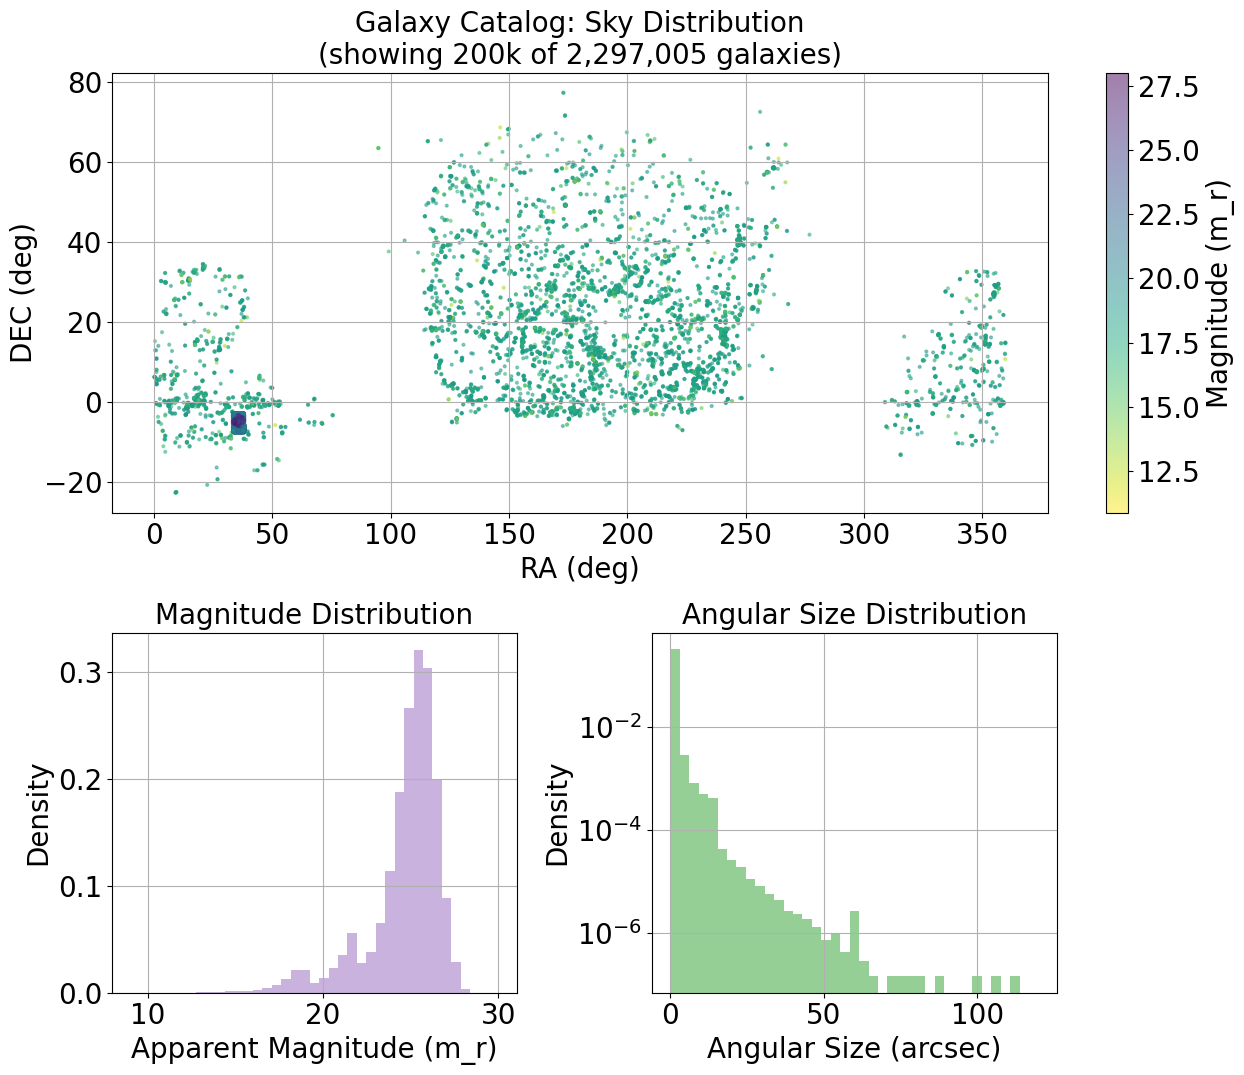

In [5]:
fig = plt.figure(figsize=(9,8))

cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

# (left, bottom, width, height)
sep_h = 0.15
sep_w = 0.1
ax_sky_distr = (0., 0.45+sep_h, 1.3, 0.55)
ax_mags = (0., 0., 0.45, 0.45)
ax_angsize = (0.5+sep_w, 0., 0.45, 0.45)

# Sky distribution
ax = plt.axes(ax_sky_distr)

# For real catalog, sample subset for visualization (too many points)
N_plot = 200000
if len(galaxies) > N_plot:
    plot_galaxies = galaxies.sample(n=N_plot, random_state=42)
    plot_title = f'Galaxy Catalog: Sky Distribution\n(showing {int(N_plot/1000)}k of {len(galaxies):,} galaxies)'
else:
    plot_galaxies = galaxies
    plot_title = 'Galaxy Catalog: Sky Distribution'

scatter = ax.scatter(plot_galaxies['ra'], plot_galaxies['dec'], 
                     c=plot_galaxies['mag_best'], s=4, alpha=0.5, cmap='viridis_r')
ax.set_xlabel('RA (deg)')
ax.set_ylabel('DEC (deg)')
ax.set_title(plot_title)
plt.colorbar(scatter, ax=ax, label='Magnitude (m_r)')
ax.grid()

# Magnitude distribution
ax = plt.axes(ax_mags)
bins = np.linspace(9., 30., 40)
ax.hist(galaxies['mag'], bins=bins, alpha=0.5, color=cycle[4], density=True)
ax.grid()
ax.set_xlabel('Apparent Magnitude (m_r)')
ax.set_ylabel('Density')
ax.set_title('Magnitude Distribution')

# Angular size distribution
ax = plt.axes(ax_angsize)
bins = np.linspace(0, 120, 40)
ax.hist(galaxies['ang_size'], bins=bins, alpha=0.5, color=cycle[2], density=True)
ax.grid()
ax.set_xlabel('Angular Size (arcsec)')
ax.set_ylabel('Density')
ax.set_title('Angular Size Distribution')
ax.set_yscale('log')

## Step 3: Assign FRBs to Host Galaxies

Now we assign FRBs to host galaxies according to their apparent magnitude. FRBs are also placed *within* their assigned host according to a chosen intrinsic offset distribution (`exponential` or `uniform`) and a localization region defined by:
- `a`: Semi-major axis (arcsec)
- `b`: Semi-minor axis (arcsec)  
- `PA`: Position angle (degrees, East of North)

We'll use a CHIME-KKO localization: a 2'' x 25'' ellipse (see typical CHIME/FRB Outrigger localizations in Figure 6 of Andersen+26).

In [5]:
# CHIME-KKO localization
localization = (25., 2., 12.)  # (a, b, PA) in arcsec, arcsec, degrees

print(f"Localization error ellipse:")
print(f"  Semi-major axis (a): {localization[0]}\"")
print(f"  Semi-minor axis (b): {localization[1]}\"")
print(f"  Position angle:      {localization[2]}°")
print()

# Assign FRBs to hosts
assignments = assign_frbs_to_hosts(
    frb_df=frbs,
    galaxy_catalog=galaxies,
    localization=localization,
    offset_function = 'exponential', 
    scale=0.5, 
    trim_catalog=60*units.arcmin,
    # mag_range=(17., 28.),  # Only assign FRBs with hosts in this mag range
    seed=seed,
)

print(f"\nSuccessfully assigned {len(assignments)} FRBs to hosts")
print(f"(Filtered from {len(frbs)} based on magnitude range)")

assignments.head(10)

Localization error ellipse:
  Semi-major axis (a): 25.0"
  Semi-minor axis (b): 2.0"
  Position angle:      12.0°

Assigning 10000 FRBs to hosts (filtered from 10000)
Iteration 1: 10000 FRBs remaining
  Brightest unassigned FRB: m_r = 10.83 deg
  Max magnitude separation: 1.9364 deg deg
Iteration 3: 47 FRBs remaining
  Brightest unassigned FRB: m_r = 11.83 deg
Iteration 4: 25 FRBs remaining
  Brightest unassigned FRB: m_r = 28.00 deg
Iteration 5: 24 FRBs remaining
  Brightest unassigned FRB: m_r = 28.00 deg
Iteration 6: 23 FRBs remaining
  Brightest unassigned FRB: m_r = 28.00 deg
Iteration 7: 22 FRBs remaining
  Brightest unassigned FRB: m_r = 28.00 deg
Iteration 8: 21 FRBs remaining
  Brightest unassigned FRB: m_r = 28.00 deg
Iteration 9: 20 FRBs remaining
  Brightest unassigned FRB: m_r = 28.00 deg
Iteration 10: 19 FRBs remaining
  Brightest unassigned FRB: m_r = 28.00 deg
Iteration 11: 18 FRBs remaining
  Brightest unassigned FRB: m_r = 28.00 deg
Iteration 12: 17 FRBs remaining
  B

,ra,dec,true_ra,true_dec,gal_ID,gal_off,mag,half_light,loc_off,FRB_ID,a,b,PA
0,34.692887,-5.326960,34.694600,-5.312589,37484700738035608,0.856394,20.936630,0.715546,52.098095,0,25.0,2.0,12.0
1,37.166779,-3.655324,37.164400,-3.668060,8796113267725806,0.503261,21.707293,0.673500,46.639254,1,25.0,2.0,12.0
2,37.497099,-5.356804,37.497276,-5.359696,8796112702865907,0.508403,19.605140,0.735599,10.429072,2,25.0,2.0,12.0
3,35.235289,-5.526316,35.235658,-5.527110,37489781684340048,0.371386,22.757252,0.537344,3.151264,3,25.0,2.0,12.0
4,4.786022,29.941542,4.786000,29.941987,8796125508273408,2.316953,18.302269,0.996600,1.602624,4,25.0,2.0,12.0
5,37.667888,-4.958335,37.664520,-4.966439,8796112797046031,2.221260,20.872950,1.549695,31.576000,5,25.0,2.0,12.0
6,143.489732,10.187432,143.487458,10.179929,8796118562571340,1.747381,16.345098,3.089763,28.186203,6,25.0,2.0,12.0
7,35.798881,-5.955200,35.798398,-5.953142,36429603367054163,0.654885,22.213486,0.530311,7.610210,7,25.0,2.0,12.0
8,35.821031,-3.703250,35.820048,-3.709322,38553705213094235,0.381872,23.449827,0.382070,22.144220,8,25.0,2.0,12.0
9,37.945484,-5.910699,37.949756,-5.894758,8796112421068228,0.025648,21.929695,0.237573,59.390705,9,25.0,2.0,12.0


## Step 4: Visualizing Distributions

Here we visualize the output host magnitudes, true galactocentric offsets, and observed FRB offsets, and how they vary depending on the input parameters (`offset_function`, `scale`, `localization`).

### Assigned Host Apparent Magnitude + Angular Size Distributions

Text(0.5, 1.15, 'Properties of Assigned Hosts')

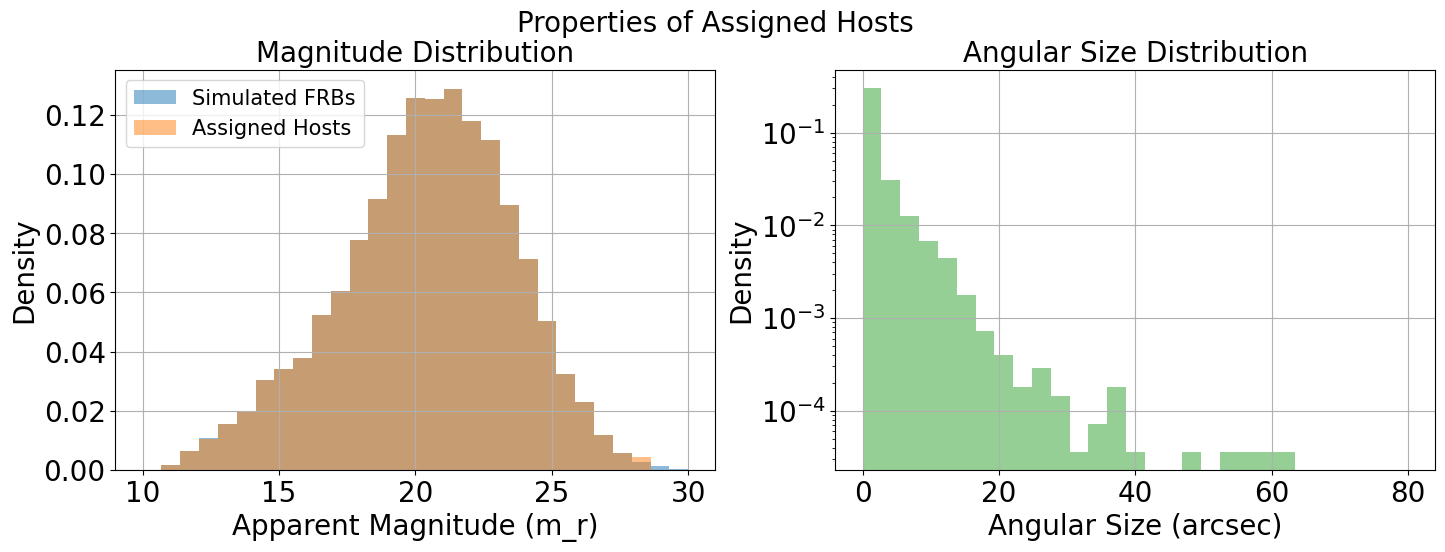

In [93]:
fig = plt.figure(figsize=(12,4))
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

# (left, bottom, width, height)
width = 0.5
sep_w = 0.1
ax_mags = (0., 0., width, 1.)
ax_angsize = (width+sep_w, 0., width, 1.)

# Magnitude distribution
ax = plt.axes(ax_mags)
bins = np.linspace(10, 30, 30)
ax.hist(frbs['m_r'], bins=bins, lw=4, alpha=0.5, color=cycle[0], density=True, label='Simulated FRBs')
ax.hist(assignments['mag'], bins=bins, lw=4, alpha=0.5, color=cycle[1], density=True, label='Assigned Hosts')
ax.grid()
ax.set_xlabel('Apparent Magnitude (m_r)')
ax.set_ylabel('Density')
ax.set_title('Magnitude Distribution')
ax.legend(fontsize=15)

# Angular size distribution
ax = plt.axes(ax_angsize)
bins = np.linspace(0, 80, 30)
ax.hist(assignments['half_light'], bins=bins, alpha=0.5, color=cycle[2], density=True)
ax.grid()
ax.set_xlabel('Angular Size (arcsec)')
ax.set_ylabel('Density')
ax.set_title('Angular Size Distribution')
ax.set_yscale('log')

plt.suptitle('Properties of Assigned Hosts', fontsize=20, y=1.15)

### True Galactocentric Offsets

Here we plot simulated examples for the intrinsic host-normalized galactocentric offset distributions.

In [7]:
# Simulate exponential
assignments_exp = assign_frbs_to_hosts(
    frb_df=frbs,
    galaxy_catalog=galaxies,
    localization=localization,
    offset_function = 'exponential', 
    scale=1., 
    trim_catalog=60*units.arcmin,
    # mag_range=(17., 28.),  # Only assign FRBs with hosts in this mag range
    seed=seed,
)

# Simlate 1D uniform
assignments_unf1d = assign_frbs_to_hosts(
    frb_df=frbs,
    galaxy_catalog=galaxies,
    localization=localization,
    offset_function = 'uniform_1d', 
    scale=6, 
    trim_catalog=60*units.arcmin,
    # mag_range=(17., 28.),  # Only assign FRBs with hosts in this mag range
    seed=seed,
)

# Simlate 2D uniform
assignments_unf2d = assign_frbs_to_hosts(
    frb_df=frbs,
    galaxy_catalog=galaxies,
    localization=localization,
    offset_function = 'uniform_2d', 
    scale=6, 
    trim_catalog=60*units.arcmin,
    # mag_range=(17., 28.),  # Only assign FRBs with hosts in this mag range
    seed=seed,
)

Assigning 10000 FRBs to hosts (filtered from 10000)
Iteration 1: 10000 FRBs remaining
  Brightest unassigned FRB: m_r = 10.83 deg
  Max magnitude separation: 1.9364 deg deg
Iteration 3: 47 FRBs remaining
  Brightest unassigned FRB: m_r = 11.83 deg
Iteration 4: 25 FRBs remaining
  Brightest unassigned FRB: m_r = 28.00 deg
Iteration 5: 24 FRBs remaining
  Brightest unassigned FRB: m_r = 28.00 deg
Iteration 6: 23 FRBs remaining
  Brightest unassigned FRB: m_r = 28.00 deg
Iteration 7: 22 FRBs remaining
  Brightest unassigned FRB: m_r = 28.00 deg
Iteration 8: 21 FRBs remaining
  Brightest unassigned FRB: m_r = 28.00 deg
Iteration 9: 20 FRBs remaining
  Brightest unassigned FRB: m_r = 28.00 deg
Iteration 10: 19 FRBs remaining
  Brightest unassigned FRB: m_r = 28.00 deg
Iteration 11: 18 FRBs remaining
  Brightest unassigned FRB: m_r = 28.00 deg
Iteration 12: 17 FRBs remaining
  Brightest unassigned FRB: m_r = 28.00 deg
Iteration 13: 16 FRBs remaining
  Brightest unassigned FRB: m_r = 28.02 de

In [8]:
# Calculate host-normalized RA/Dec offsets and radial offsets
def calculate_offsets(assignments, galaxies, N=10000):
    gal_cols = galaxies[['ID', 'ra', 'dec', 'half_light']].rename(columns={
        'ra':         'gal_ra',
        'dec':        'gal_dec',
        'half_light': 'gal_half_light',
    })

    merged = assignments[:N].merge(gal_cols, left_on='gal_ID', right_on='ID')

    cos_dec = np.cos(np.radians(merged['gal_dec'].values))

    sampled_ra_offsets = (merged['gal_ra'].values - merged['true_ra'].values) * cos_dec * 3600 / merged['gal_half_light'].values
    sampled_dec_offsets = (merged['gal_dec'].values - merged['true_dec'].values) * 3600 / merged['gal_half_light'].values
    sampled_r_offsets = np.sqrt(sampled_ra_offsets**2 + sampled_dec_offsets**2)

    return sampled_ra_offsets, sampled_dec_offsets, sampled_r_offsets

print("Calculating exponential offsets")
sampled_ra_offsets_exp, sampled_dec_offsets_exp, sampled_r_offsets_exp = calculate_offsets(assignments_exp, galaxies)

print("Calculating 1D uniform offsets")
sampled_ra_offsets_unf1d, sampled_dec_offsets_unf1d, sampled_r_offsets_unf1d = calculate_offsets(assignments_unf1d, galaxies)

print("Calculating 2D uniform offsets")
sampled_ra_offsets_unf2d, sampled_dec_offsets_unf2d, sampled_r_offsets_unf2d = calculate_offsets(assignments_unf2d, galaxies)

Calculating exponential offsets
Calculating 1D uniform offsets
Calculating 2D uniform offsets


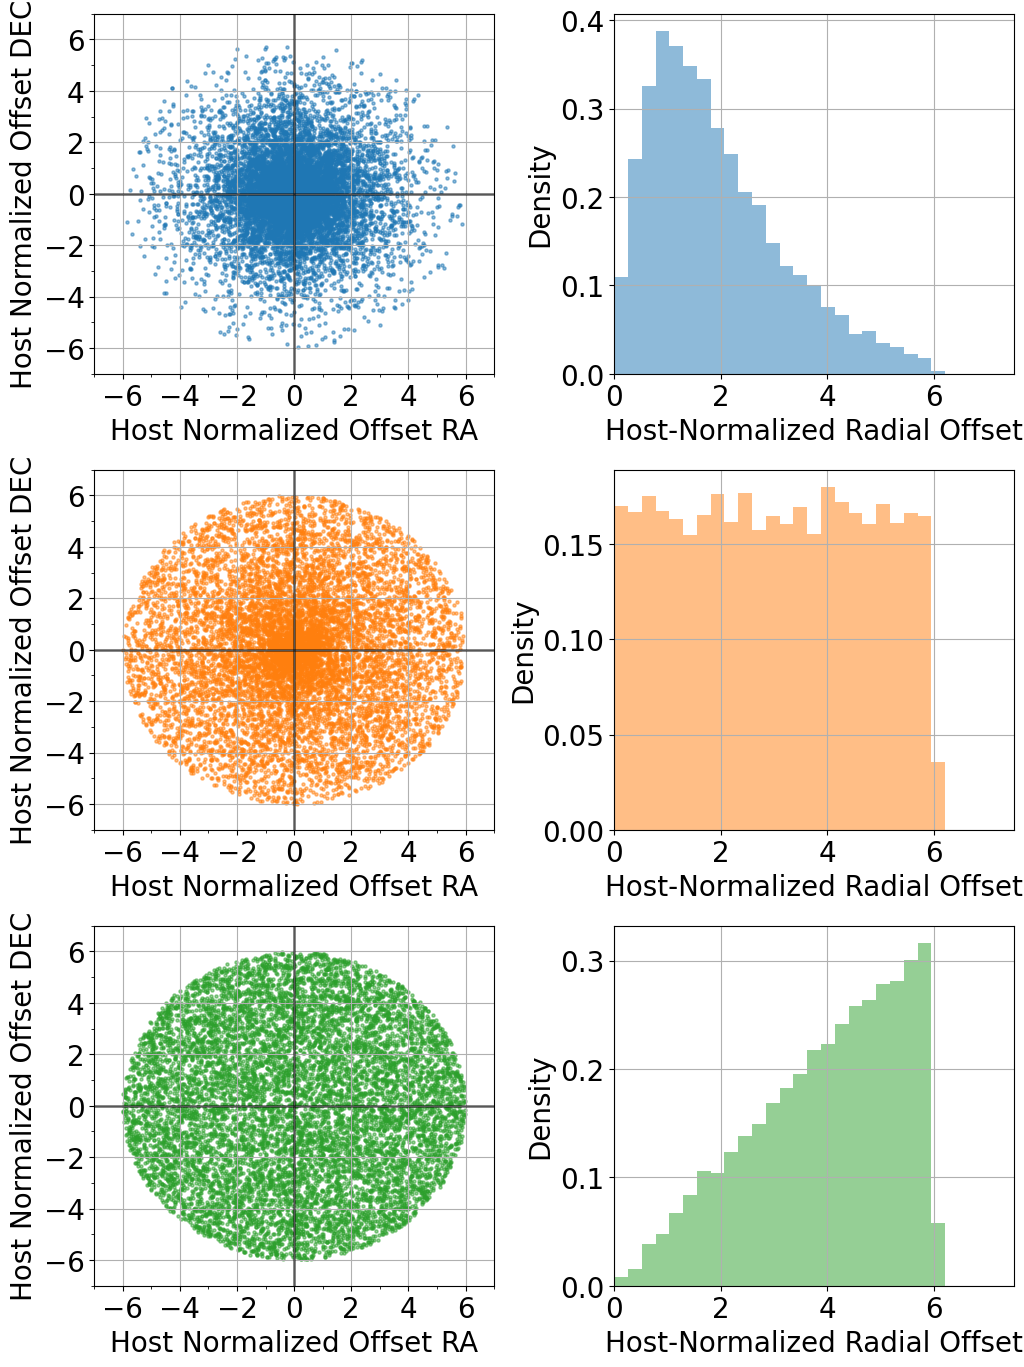

In [13]:
fig = plt.figure(figsize=(8,12))
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

# (left, bottom, width, height)
height = 0.3
width = 0.5
sep_h = 0.08
sep_w = 0.15
ax_2d_exp = (0, 3*(height+sep_h), width, height)
ax_1d_exp = (width+sep_w, 3*(height+sep_h), width, height)
ax_2d_unf1d = (0, 2*(height+sep_h), width, height)
ax_1d_unf1d = (width+sep_w, 2*(height+sep_h), width, height)
ax_2d_unf2d = (0, 1*(height+sep_h), width, height)
ax_1d_unf2d = (width+sep_w, 1*(height+sep_h), width, height)

ax = plt.axes(ax_2d_exp)

xlim = 7
ylim = 7

# Set up the grid
ax.axvline(x=0, lw=2, color='black', alpha=0.5)
ax.axhline(y=0, lw=2, color='black', alpha=0.5)
ax.set_xlabel('Host Normalized Offset RA')
ax.set_ylabel('Host Normalized Offset DEC')
ax.set_xlim([-xlim,xlim])
ax.set_ylim([-ylim,ylim])
ax.grid()
ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(1))
    
ax.scatter(
    sampled_ra_offsets_exp, sampled_dec_offsets_exp, alpha=0.5,
    color=cycle[0], s=5,
)

ax = plt.axes(ax_1d_exp)

max_lim = np.nanmax([xlim, ylim]) + 0.5
bins = np.linspace(0., max_lim, 30)
ax.hist(sampled_r_offsets_exp, bins=bins, alpha=0.5, color=cycle[0], density=True)
ax.set_xlim([0,max_lim])
ax.set_xlabel('Host-Normalized Radial Offset')
ax.set_ylabel('Density')
ax.grid()

ax = plt.axes(ax_2d_unf1d)

# Set up the grid
ax.axvline(x=0, lw=2, color='black', alpha=0.5)
ax.axhline(y=0, lw=2, color='black', alpha=0.5)
ax.set_xlabel('Host Normalized Offset RA')
ax.set_ylabel('Host Normalized Offset DEC')
ax.set_xlim([-xlim,xlim])
ax.set_ylim([-ylim,ylim])
ax.grid()
ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(1))
    
ax.scatter(
    sampled_ra_offsets_unf1d, sampled_dec_offsets_unf1d, alpha=0.5,
    color=cycle[1], s=5,
)

ax = plt.axes(ax_1d_unf1d)

max_lim = np.nanmax([xlim, ylim]) + 0.5
bins = np.linspace(0., max_lim, 30)
ax.hist(sampled_r_offsets_unf1d, bins=bins, alpha=0.5, color=cycle[1], density=True)
ax.set_xlim([0,max_lim])
ax.set_xlabel('Host-Normalized Radial Offset')
ax.set_ylabel('Density')
ax.grid()

ax = plt.axes(ax_2d_unf2d)

# Set up the grid
ax.axvline(x=0, lw=2, color='black', alpha=0.5)
ax.axhline(y=0, lw=2, color='black', alpha=0.5)
ax.set_xlabel('Host Normalized Offset RA')
ax.set_ylabel('Host Normalized Offset DEC')
ax.set_xlim([-xlim,xlim])
ax.set_ylim([-ylim,ylim])
ax.grid()
ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(1))
    
ax.scatter(
    sampled_ra_offsets_unf2d, sampled_dec_offsets_unf2d, alpha=0.5,
    color=cycle[2], s=5,
)

ax = plt.axes(ax_1d_unf2d)

max_lim = np.nanmax([xlim, ylim]) + 0.5
bins = np.linspace(0., max_lim, 30)
ax.hist(sampled_r_offsets_unf2d, bins=bins, alpha=0.5, color=cycle[2], density=True)
ax.set_xlim([0,max_lim])
ax.set_xlabel('Host-Normalized Radial Offset')
ax.set_ylabel('Density')
ax.grid()

In [52]:
# Simulate exponentials with a range of scales
scales = [2., 1., 0.5]

offset_sims = {}
for scale in scales:
    print("Simulating scale: {}''".format(scale))
    # Simulate exponential
    assignments = assign_frbs_to_hosts(
        frb_df=frbs,
        galaxy_catalog=galaxies,
        localization=localization,
        offset_function = 'exponential', 
        scale=scale, 
        trim_catalog=60*units.arcmin,
        # mag_range=(17., 28.),  # Only assign FRBs with hosts in this mag range
        seed=seed,
    )
    
    sampled_ra_offsets, sampled_dec_offsets, sampled_r_offsets = calculate_offsets(assignments, galaxies)
    
    offset_sims[scale] = {
        'sampled_ra_offsets' : sampled_ra_offsets,
        'sampled_dec_offsets' : sampled_dec_offsets,
        'sampled_r_offsets' : sampled_r_offsets,
    }

Simulating scale: 2.0''
Assigning 10000 FRBs to hosts (filtered from 10000)
Iteration 1: 10000 FRBs remaining
  Brightest unassigned FRB: m_r = 10.83 deg
  Max magnitude separation: 1.9364 deg deg
Iteration 3: 47 FRBs remaining
  Brightest unassigned FRB: m_r = 11.83 deg
Iteration 4: 25 FRBs remaining
  Brightest unassigned FRB: m_r = 28.00 deg
Iteration 5: 24 FRBs remaining
  Brightest unassigned FRB: m_r = 28.00 deg
Iteration 6: 23 FRBs remaining
  Brightest unassigned FRB: m_r = 28.00 deg
Iteration 7: 22 FRBs remaining
  Brightest unassigned FRB: m_r = 28.00 deg
Iteration 8: 21 FRBs remaining
  Brightest unassigned FRB: m_r = 28.00 deg
Iteration 9: 20 FRBs remaining
  Brightest unassigned FRB: m_r = 28.00 deg
Iteration 10: 19 FRBs remaining
  Brightest unassigned FRB: m_r = 28.00 deg
Iteration 11: 18 FRBs remaining
  Brightest unassigned FRB: m_r = 28.00 deg
Iteration 12: 17 FRBs remaining
  Brightest unassigned FRB: m_r = 28.00 deg
Iteration 13: 16 FRBs remaining
  Brightest unassi

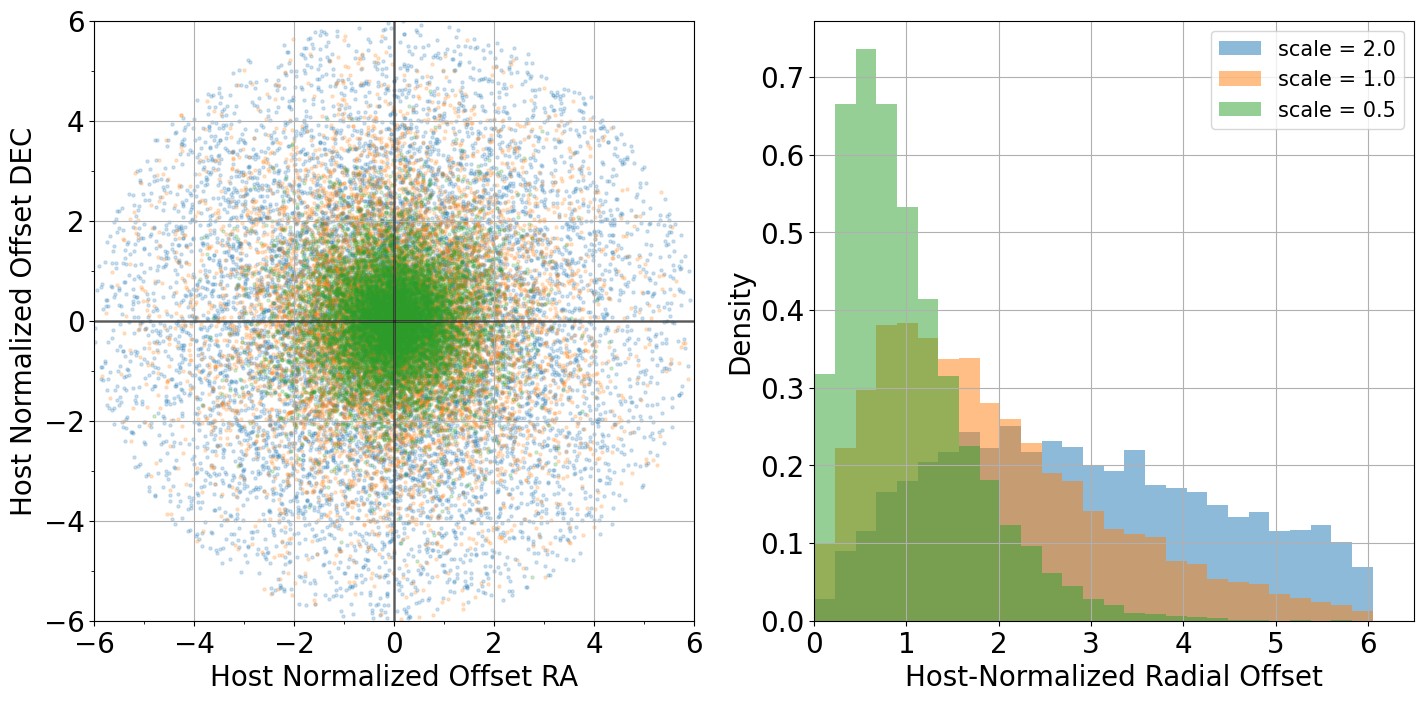

In [53]:
fig = plt.figure(figsize=(12,6))

# (left, bottom, width, height)
sep_h = 0.1
sep_w = 0.1
ax_2d = (0, 0., 0.5, 1.)
ax_1d = (0.5+sep_w, 0., 0.5, 1.)

ax = plt.axes(ax_2d)

xlim = 6
ylim = 6

# Set up the grid
ax.axvline(x=0, lw=2, color='black', alpha=0.5)
ax.axhline(y=0, lw=2, color='black', alpha=0.5)
ax.set_xlabel('Host Normalized Offset RA')
ax.set_ylabel('Host Normalized Offset DEC')
ax.set_xlim([-xlim,xlim])
ax.set_ylim([-ylim,ylim])
ax.grid()
ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(1))

for ii in range(len(scales)):
    scale = scales[ii]
    sampled_ra_offsets = offset_sims[scale]['sampled_ra_offsets']
    sampled_dec_offsets = offset_sims[scale]['sampled_dec_offsets']
    sampled_r_offsets = offset_sims[scale]['sampled_r_offsets']
    
    ax.scatter(
        sampled_ra_offsets, sampled_dec_offsets, alpha=0.2,
        color=cycle[ii], s=5, label='scale = {}'.format(scale),
    )

ax = plt.axes(ax_1d)

max_lim = np.nanmax([xlim, ylim]) + 0.5
bins = np.linspace(0., max_lim, 30)
ax.set_xlim([0,max_lim])
ax.set_xlabel('Host-Normalized Radial Offset')
ax.set_ylabel('Density')
ax.grid()

for ii in range(len(scales)):
    scale = scales[ii]
    sampled_ra_offsets = offset_sims[scale]['sampled_ra_offsets']
    sampled_dec_offsets = offset_sims[scale]['sampled_dec_offsets']
    sampled_r_offsets = offset_sims[scale]['sampled_r_offsets']
    
    ax.hist(
        sampled_r_offsets, bins=bins, alpha=0.5, 
        color=cycle[ii], density=True, label='scale = {}'.format(scale),
    )
ax.legend(fontsize=15)

### Localization Sizes

Here we plot simulated examples of the actual observed host-normalized galactocentric offset distributions, with different-sized localizations.

In [75]:
# Calculate host-normalized RA/Dec offsets and radial offsets
def calculate_offsets(assignments, galaxies, N=10000):
    gal_cols = galaxies[['ID', 'ra', 'dec', 'half_light']].rename(columns={
        'ra':         'gal_ra',
        'dec':        'gal_dec',
        'half_light': 'gal_half_light',
    })

    merged = assignments[:N].merge(gal_cols, left_on='gal_ID', right_on='ID')

    cos_dec = np.cos(np.radians(merged['gal_dec'].values))

    sampled_ra_offsets = (merged['gal_ra'].values - merged['ra'].values) * cos_dec * 3600 / merged['gal_half_light'].values
    sampled_dec_offsets = (merged['gal_dec'].values - merged['dec'].values) * 3600 / merged['gal_half_light'].values
    sampled_r_offsets = np.sqrt(sampled_ra_offsets**2 + sampled_dec_offsets**2)

    return sampled_ra_offsets, sampled_dec_offsets, sampled_r_offsets

In [76]:
# Simulate a range of localization sizes
locs = [
    (0.1, 0.05, 10), # CHIME/FRB Outriggers full-array localization
    (1., 1., 0.), # 1''
    (25., 2., 12.), # CHIME-KKO
]

offset_sims = {}
for loc in locs:
    print("Simulating localization: {}''".format(loc))
    # Simulate exponential
    assignments = assign_frbs_to_hosts(
        frb_df=frbs,
        galaxy_catalog=galaxies,
        localization=loc,
        offset_function = 'exponential', 
        scale=0.5, 
        trim_catalog=60*units.arcmin,
        # mag_range=(17., 28.),  # Only assign FRBs with hosts in this mag range
        seed=seed,
    )
    
    sampled_ra_offsets, sampled_dec_offsets, sampled_r_offsets = calculate_offsets(assignments, galaxies)
    
    offset_sims[loc] = {
        'sampled_ra_offsets' : sampled_ra_offsets,
        'sampled_dec_offsets' : sampled_dec_offsets,
        'sampled_r_offsets' : sampled_r_offsets,
    }

Simulating localization: (0.1, 0.05, 10)''
Assigning 10000 FRBs to hosts (filtered from 10000)
Iteration 1: 10000 FRBs remaining
  Brightest unassigned FRB: m_r = 10.83 deg
  Max magnitude separation: 1.9364 deg deg
Iteration 3: 47 FRBs remaining
  Brightest unassigned FRB: m_r = 11.83 deg
Iteration 4: 25 FRBs remaining
  Brightest unassigned FRB: m_r = 28.00 deg
Iteration 5: 24 FRBs remaining
  Brightest unassigned FRB: m_r = 28.00 deg
Iteration 6: 23 FRBs remaining
  Brightest unassigned FRB: m_r = 28.00 deg
Iteration 7: 22 FRBs remaining
  Brightest unassigned FRB: m_r = 28.00 deg
Iteration 8: 21 FRBs remaining
  Brightest unassigned FRB: m_r = 28.00 deg
Iteration 9: 20 FRBs remaining
  Brightest unassigned FRB: m_r = 28.00 deg
Iteration 10: 19 FRBs remaining
  Brightest unassigned FRB: m_r = 28.00 deg
Iteration 11: 18 FRBs remaining
  Brightest unassigned FRB: m_r = 28.00 deg
Iteration 12: 17 FRBs remaining
  Brightest unassigned FRB: m_r = 28.00 deg
Iteration 13: 16 FRBs remaining

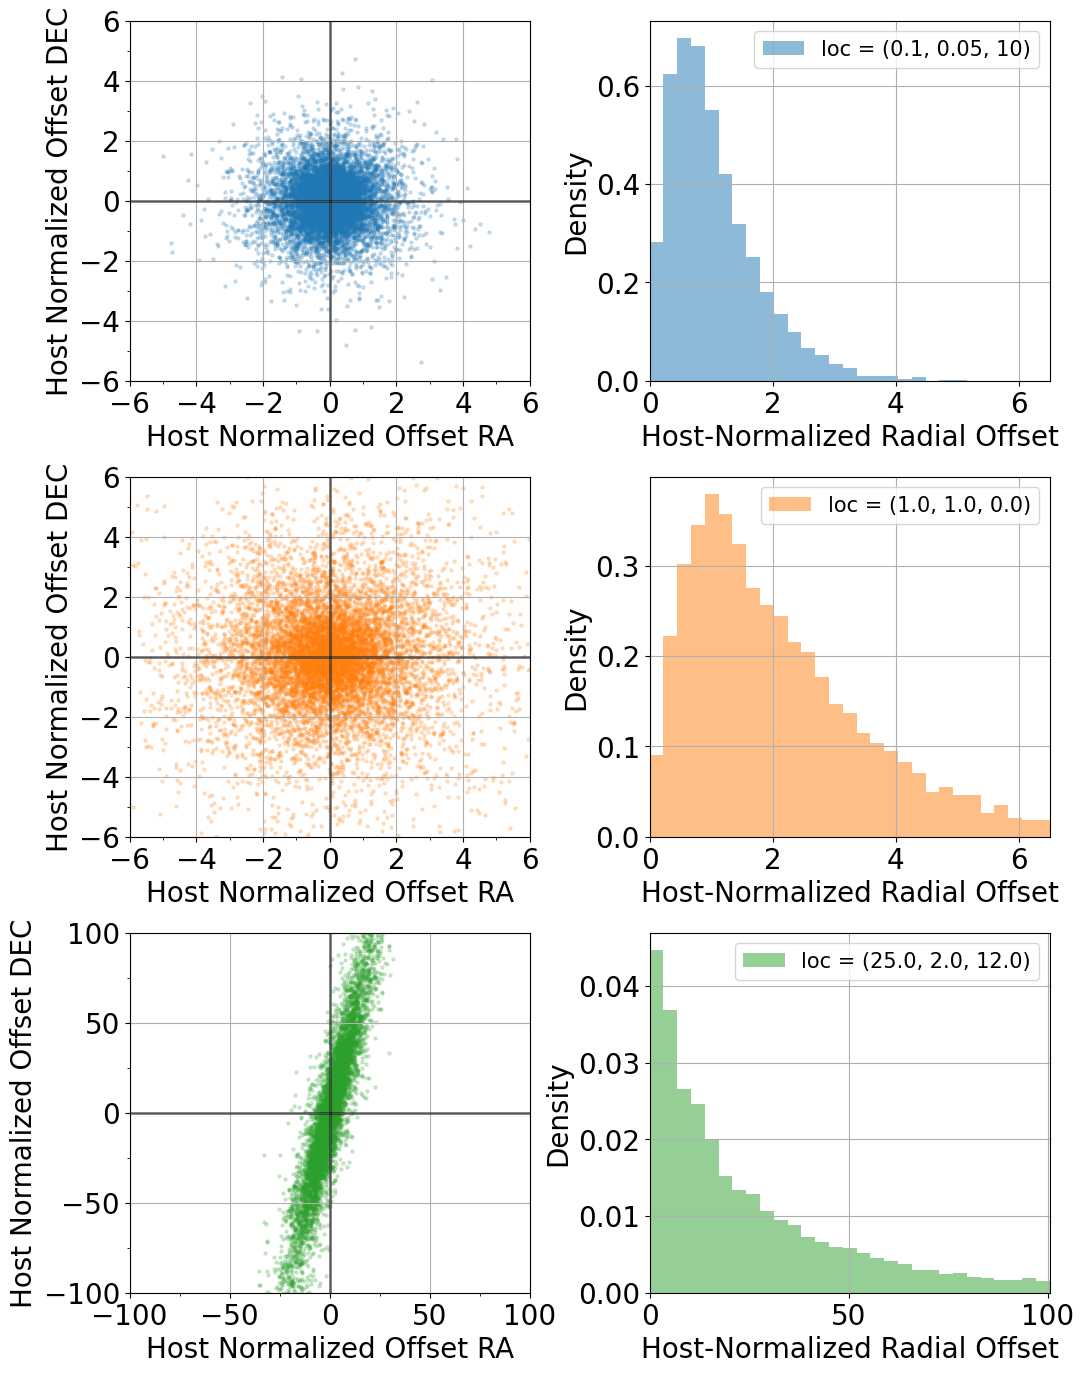

In [86]:
fig = plt.figure(figsize=(8,12))

# (left, bottom, width, height)
height = 0.3
width = 0.5
sep_h = 0.08
sep_w = 0.15
ax_2d_fa = (0, 3*(height+sep_h), width, height)
ax_1d_fa = (width+sep_w, 3*(height+sep_h), width, height)
ax_2d_1as = (0, 2*(height+sep_h), width, height)
ax_1d_1as = (width+sep_w, 2*(height+sep_h), width, height)
ax_2d_ck = (0, 1*(height+sep_h), width, height)
ax_1d_ck = (width+sep_w, 1*(height+sep_h), width, height)

ax_loc = {
    locs[0] : [ax_2d_fa, ax_1d_fa],
    locs[1] : [ax_2d_1as, ax_1d_1as],
    locs[2] : [ax_2d_ck, ax_1d_ck],
}

lims = {
    locs[0] : [6, 6],
    locs[1] : [6, 6],
    locs[2] : [100, 100],
}

ticks = {
    locs[0] : [2, 1],
    locs[1] : [2, 1],
    locs[2] : [50, 25],
}

for ii in range(len(locs)):
    loc = locs[ii]
    ax = plt.axes(ax_loc[loc][0])

    xlim = lims[loc][0]
    ylim = lims[loc][1]
    
    tick = ticks[loc]

    # Set up the grid
    ax.axvline(x=0, lw=2, color='black', alpha=0.5)
    ax.axhline(y=0, lw=2, color='black', alpha=0.5)
    ax.set_xlabel('Host Normalized Offset RA')
    ax.set_ylabel('Host Normalized Offset DEC')
    ax.set_xlim([-xlim,xlim])
    ax.set_ylim([-ylim,ylim])
    ax.grid()
    ax.xaxis.set_major_locator(ticker.MultipleLocator(tick[0]))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(tick[1]))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(tick[0]))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(tick[1]))

    sampled_ra_offsets = offset_sims[loc]['sampled_ra_offsets']
    sampled_dec_offsets = offset_sims[loc]['sampled_dec_offsets']
    sampled_r_offsets = offset_sims[loc]['sampled_r_offsets']

    ax.scatter(
        sampled_ra_offsets, sampled_dec_offsets, alpha=0.2,
        color=cycle[ii], s=5, label='loc = {}'.format(loc),
    )

    ax = plt.axes(ax_loc[loc][1])

    max_lim = np.nanmax([xlim, ylim]) + 0.5
    bins = np.linspace(0., max_lim, 30)
    ax.set_xlim([0,max_lim])
    ax.set_xlabel('Host-Normalized Radial Offset')
    ax.set_ylabel('Density')
    ax.grid()

    ax.hist(
        sampled_r_offsets, bins=bins, alpha=0.5, 
        color=cycle[ii], density=True, label='loc = {}'.format(loc),
    )
    ax.legend(fontsize=15)

## Step 5: Saving Results

Save the assignment results for later use or PATH analysis.

In [94]:
# Save to CSV
# assignments.to_csv('frb_host_assignments.csv', index=False)
print("Example: Save to CSV")
print("  assignments.to_csv('frb_host_assignments.csv', index=False)")

# Save to Parquet (more efficient for large datasets)
# assignments.to_parquet('frb_host_assignments.parquet', index=False)
print("\nExample: Save to Parquet")
print("  assignments.to_parquet('frb_host_assignments.parquet', index=False)")

print("\nOutput columns:")
for col in assignments.columns:
    print(f"  - {col}")

Example: Save to CSV
  assignments.to_csv('frb_host_assignments.csv', index=False)

Example: Save to Parquet
  assignments.to_parquet('frb_host_assignments.parquet', index=False)

Output columns:
  - ra
  - dec
  - true_ra
  - true_dec
  - gal_ID
  - gal_off
  - mag
  - half_light
  - loc_off
  - FRB_ID
  - a
  - b
  - PA
